### This notebook compute "VCA12. Denisty Index of hydrometerological monitoring network stations in the basin" indicator for the 27 basins of IKI Project

Spanish: Índice de densidad de estaciones de la red de monitoreo hidrometeorológico en la cuenca

**Created:** 10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** Complete and loaded in SQLite. 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, Hidrometricas_SENAMHI_ANA_1980_2020

**Process:**
o Divide el área de la cuenca en km² entre la densidad mínima de estaciones en km² sugerida 
por la Organización Meteorológica Mundial (OMM), es decir, 250 km²34. De acuerdo a la 
OMM, se recomienda contar con 1 estación por cada 250 km².
o Divide el número de estaciones que se encuentran funcionando en la cuenca entre el 
resultado obtenido en el cálculo anterior.
o Asigna el índice obtenido por cuenca a todos sus distritos correspondientes
 
**Assumptions:** Calcualting one value for the entire watershed and assigning the same value to all COMIDs within the watershed. Depending on the scale of analysis this might not be that telling of an indicator. 
 
**Future work:**  Possibly modify to find the number of stations per area of drenaje (as calculated using the AHD, query the the base de datos to calculate the total area de drenaje). This would require querying the database and calculating the area each time. 

 
**Notes:** 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
#SETTINGS 

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 512 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [3]:
#INPUTS

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in shapefiles 

#read in bocatomas
stations_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/hidrometricas_ANA_SENAMHI_1981-2020.shp'

#CRS CHECK

# Ensure all infrastructure shapefiles have the same CRS as the subbasin shapefile
subbasins_crs = subbasins_gdf.crs  # Get the CRS of the subbasin shapefile

# Reproject infrastructure shapefiles to match the subbasin CRS
stations_gdf = gpd.read_file(stations_shp).to_crs(subbasins_crs)


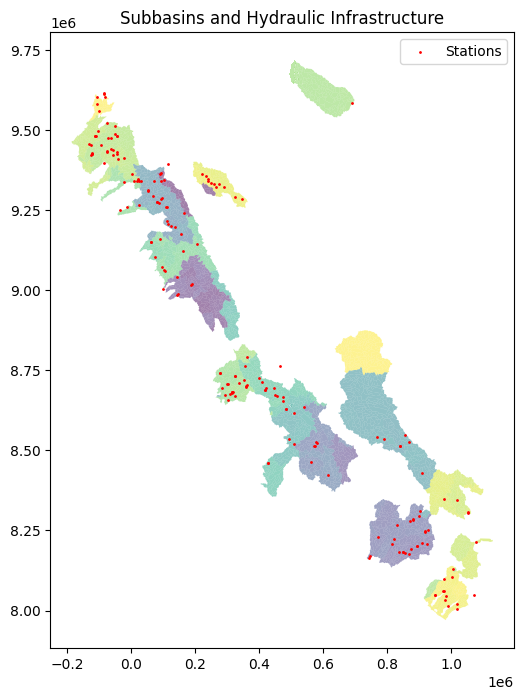

In [4]:
#PLOT TO ENSURE ALIGNMENT 

# Plot subbasins and bocatomas on the same plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot subbasins
subbasins_gdf.plot(ax=ax, column='IDDIST', legend=True, cmap='viridis', alpha=0.5)

# Plot stations
stations_gdf.plot(ax=ax, color='red', markersize=1, label='Stations')

# Add title and legend
plt.title('Subbasins and Hydraulic Infrastructure')
plt.legend()

# Show the plot
plt.show()

In [5]:
#COUNT FEATURES PER CUENCA (BASIN)

# Calculate density per Cuenca
# Group COMIDs by Cuenca and calculate total stations and area for each Cuenca

# Add area in km2 to subbasins_gdf if not already present
if 'Area_km2' not in subbasins_gdf.columns:
    subbasins_gdf['Area_km2'] = subbasins_gdf.geometry.to_crs(epsg=6933).area / 10**6

# Group by Cuenca to get total area per cuenca
cuenca_areas = subbasins_gdf.groupby('Cuenca')['Area_km2'].sum().reset_index()
cuenca_areas = cuenca_areas.rename(columns={'Area_km2': 'Cuenca_Area_km2'})

# Count stations per cuenca
# First, do a spatial join to assign each station to a COMID
stations_with_comid = gpd.sjoin(stations_gdf, subbasins_gdf[['COMID', 'Cuenca', 'geometry']], 
                                  how='left', predicate='within')

# Count unique stations per Cuenca
cuenca_station_counts = stations_with_comid.groupby('Cuenca').size().reset_index(name='Station_Count')

# Merge area and station counts
cuenca_data = cuenca_areas.merge(cuenca_station_counts, on='Cuenca', how='left')
cuenca_data['Station_Count'] = cuenca_data['Station_Count'].fillna(0)

# Calculate density per Cuenca (stations / (area / 250))
cuenca_data['Cuenca_Density'] = (cuenca_data['Station_Count'] / (cuenca_data['Cuenca_Area_km2'] / 250)).round(2)

print("\nStation Density per Cuenca:")
print(cuenca_data)

# Assign Cuenca-level density to all COMIDs within that Cuenca
subbasins_gdf = subbasins_gdf.merge(cuenca_data[['Cuenca', 'Station_Count', 'Cuenca_Area_km2', 'Cuenca_Density']], 
                                      on='Cuenca', how='left')


Station Density per Cuenca:
                           Cuenca  Cuenca_Area_km2  Station_Count  \
0             Cuenca Alto Marañon     45776.242439           30.0   
1                   Cuenca Camana     17033.546069           10.0   
2                  Cuenca Caplina      1239.992006            1.0   
3                 Cuenca Cascajal      4140.577935            0.0   
4         Cuenca Chancay - Huaral      3084.535314            2.0   
5       Cuenca Chancay-Lambayeque      4143.413556            1.0   
6                  Cuenca Chicama      4624.731588            3.0   
7                  Cuenca Chillon      2188.403131            5.0   
8                    Cuenca Chira     17870.833757           13.0   
9               Cuenca Huamansaña      1440.942255            2.0   
10                     Cuenca Ica      7380.417056            2.0   
11                   Cuenca Ilave      8188.241068            1.0   
12              Cuenca Lacramarca       793.401404            0.0   
13   

In [6]:
#MERGE TO SUBBASINS GDF

# Data already merged in previous cell - Cuenca-level density assigned to all COMIDs
print(f"Total COMIDs: {len(subbasins_gdf)}")
print(f"Unique Cuencas: {subbasins_gdf['Cuenca'].nunique()}")
print(f"\nSample of data:")
print(subbasins_gdf[['COMID', 'Cuenca', 'Station_Count', 'Cuenca_Area_km2', 'Cuenca_Density']].head(10))


Total COMIDs: 3655
Unique Cuencas: 33

Sample of data:
       COMID                     Cuenca  Station_Count  Cuenca_Area_km2  \
0  311153600               Cuenca Ilave            1.0      8188.241068   
1  310832400               Cuenca Ramis            4.0     15730.640502   
2  310825700               Cuenca Ramis            4.0     15730.640502   
3  310282400                 Cuenca Ica            2.0      7380.417056   
4  308754600             Cuenca Mantaro           20.0     34543.013154   
5  307736500               Cuenca Santa            3.0     11636.274541   
6  307078200             Cuenca Chicama            3.0      4624.731588   
7  307183500               Cuenca Moche            1.0      2121.718832   
8  306538400  Cuenca Chancay-Lambayeque            1.0      4143.413556   
9  306599700  Cuenca Chancay-Lambayeque            1.0      4143.413556   

   Cuenca_Density  
0            0.03  
1            0.06  
2            0.06  
3            0.07  
4            0.14  

In [7]:
#CALCULATION OF INDICATOR VALUE TO FIND DENSITY OF FEATURES PER 250 KM2

# Use Cuenca-level density (calculated in previous cell)
# Assign to 'value' column for database insert
subbasins_gdf['value'] = subbasins_gdf['Cuenca_Density'].round(2)

print(f"\nDensity Value Summary (by Cuenca):")
print(subbasins_gdf.groupby('Cuenca')[['value', 'Station_Count', 'Cuenca_Area_km2']].first())



Density Value Summary (by Cuenca):
                               value  Station_Count  Cuenca_Area_km2
Cuenca                                                              
Cuenca Alto Marañon             0.16           30.0     45776.242439
Cuenca Camana                   0.15           10.0     17033.546069
Cuenca Caplina                  0.20            1.0      1239.992006
Cuenca Cascajal                 0.00            0.0      4140.577935
Cuenca Chancay - Huaral         0.16            2.0      3084.535314
Cuenca Chancay-Lambayeque       0.06            1.0      4143.413556
Cuenca Chicama                  0.16            3.0      4624.731588
Cuenca Chillon                  0.57            5.0      2188.403131
Cuenca Chira                    0.18           13.0     17870.833757
Cuenca Huamansaña               0.35            2.0      1440.942255
Cuenca Ica                      0.07            2.0      7380.417056
Cuenca Ilave                    0.03            1.0      8188.24106

count    3608.000000
mean        0.132658
std         0.115086
min         0.020000
25%         0.040000
50%         0.140000
75%         0.160000
max         0.840000
Name: value, dtype: float64

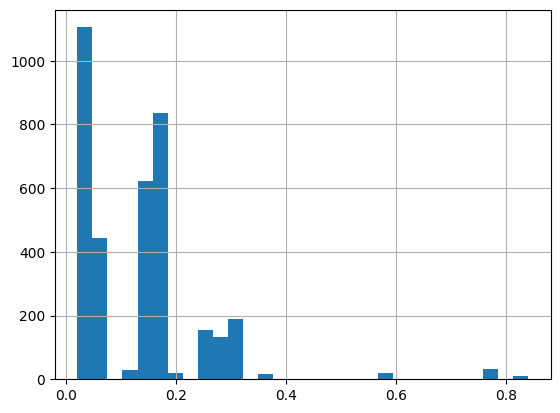

In [8]:
#QC HISTOGRAM AND SUMMARY STATS

#histogram of value above, excluding zeros
subbasins_gdf['value'][subbasins_gdf['value'] > 0].hist(bins=30)

#visual summary table, excluding zeros
subbasins_gdf['value'][subbasins_gdf['value'] > 0].describe()

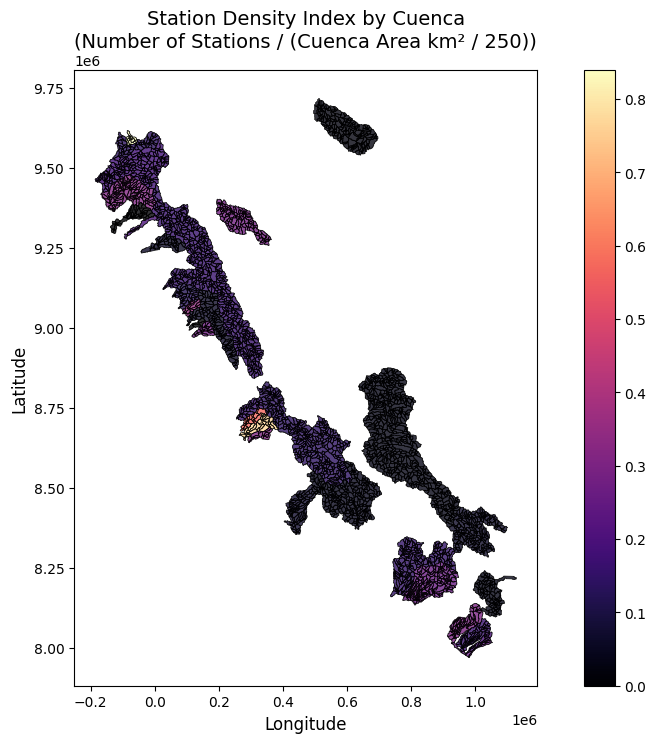

This reflects the WMO recommendation of 1 station per 250 km² at the basin (Cuenca) level

Note: All COMIDs within the same Cuenca have the same density value


In [9]:
# Plot the basins colored by station density (Cuenca-level)
fig, ax = plt.subplots(figsize=(12, 8))
subbasins_gdf.plot(ax=ax, column='value', legend=True, cmap='magma', alpha=0.8, edgecolor='black', linewidth=0.5)

# Add title and labels
plt.title('Station Density Index by Cuenca\n(Number of Stations / (Cuenca Area km² / 250))', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Show the plot
plt.show()

print(f"This reflects the WMO recommendation of 1 station per 250 km² at the basin (Cuenca) level")
print(f"\nNote: All COMIDs within the same Cuenca have the same density value")

SQLITE INSERT 

In [10]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID 
value_column= 'value'

In [11]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [12]:
rows_to_insert

[(1, 512, 311153600, 0.03),
 (1, 512, 310832400, 0.06),
 (1, 512, 310825700, 0.06),
 (1, 512, 310282400, 0.07),
 (1, 512, 308754600, 0.14),
 (1, 512, 307736500, 0.06),
 (1, 512, 307078200, 0.16),
 (1, 512, 307183500, 0.12),
 (1, 512, 306538400, 0.06),
 (1, 512, 306599700, 0.06),
 (1, 512, 306319300, 0.2),
 (1, 512, 306030000, 0.0),
 (1, 512, 305746400, 0.31),
 (1, 512, 311953100, 0.16),
 (1, 512, 304273900, 0.02),
 (1, 512, 304281100, 0.02),
 (1, 512, 304281200, 0.02),
 (1, 512, 304379300, 0.02),
 (1, 512, 304274000, 0.02),
 (1, 512, 304313700, 0.02),
 (1, 512, 304306400, 0.02),
 (1, 512, 304327700, 0.02),
 (1, 512, 304313800, 0.02),
 (1, 512, 304306300, 0.02),
 (1, 512, 304321600, 0.02),
 (1, 512, 304321700, 0.02),
 (1, 512, 304339400, 0.02),
 (1, 512, 304335700, 0.02),
 (1, 512, 304343200, 0.02),
 (1, 512, 304343100, 0.02),
 (1, 512, 304335800, 0.02),
 (1, 512, 304343000, 0.02),
 (1, 512, 304330900, 0.02),
 (1, 512, 304352700, 0.02),
 (1, 512, 304421200, 0.02),
 (1, 512, 304403000, 0

In [13]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [14]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()